In [303]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.patches as patches

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

sns.set_palette("tab10")
sns.set_style("whitegrid")
plt.rc("font", size=12)

# =========================
# User parameters
# =========================
T_D = 1.0 # (T_D = T_D * L_SD)

# T_I = 3.0 # Qwen
# T_T = 6.0 # Qwen

# T_I = 3.0 # Llama 8B
# T_T = 9.0 # Llama 70B

T_I = 6.0 # Llama 70B FP8
T_T = 9.0 # Llama 70B 

# alpha_SD = 0.798 # Qwen
# alpha_HV = 0.853 # Qwen

alpha_SD = 0.848 # Llama
alpha_HV = 0.95 # Llama

# alpha_HV = 0.9

S_AR = 1.0

L_SD_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

L_SD_values = [1, 3, 5, 7, 9, 11, 13, 15]
R_values = [1, 2, 3, 4, 5]

fixed_R = 1
fixed_L_SD = 3

# =========================
# Pivot parameters
# =========================
misspeculation_probability = 0.138
pivot_top_k = 5
pivot_pct = 0.2
pivot_reduce_misspec = 0.80

# Expansion overhead:
# top-k expansion adds k-1 extra branches for pivot_pct fraction of requests
pivot_expansion_factor = 1.0 + pivot_pct * (pivot_top_k - 1)

plots_dir = "./plots_analytical"
os.makedirs(plots_dir, exist_ok=True)

# =========================
# Analytical model
# =========================
def avg_commit_len(alpha, L):
    if np.isclose(alpha, 1.0):
        return L + 1
    return (1.0 - alpha ** (L + 1)) / (1.0 - alpha)

def sd_speedup_vs_ar(L_SD, alpha_SD, T_D, T_T):
    T_D = L_SD * T_D
    A_SD = avg_commit_len(alpha_SD, L_SD)
    S_SD = S_AR / A_SD
    T_AR_total = S_AR * T_T
    T_SD_total = S_SD * (T_D + T_T)
    return T_AR_total / T_SD_total

def hv_speedup_vs_ar(L_SD, R, alpha_HV, T_D, T_I, T_T):
    T_D = L_SD * T_D
    L_HV = (L_SD + 1) * R + L_SD
    A_HV = avg_commit_len(alpha_HV, L_HV)
    S_HV = S_AR / A_HV

    hv_cost_per_step = (R + 1) * T_D + (R * T_I) + (T_T * 1.2)  # 1.2 is the overhead for expanding verification lengths
    T_AR_total = S_AR * T_T
    T_HV_total = S_HV * hv_cost_per_step
    return T_AR_total / T_HV_total





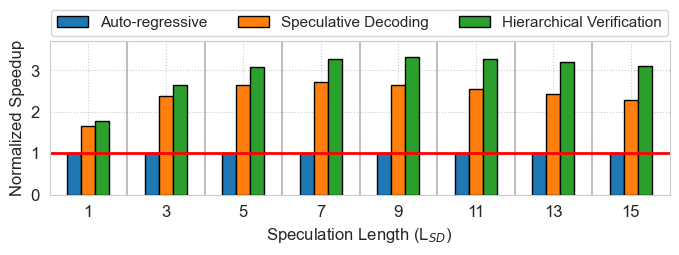

In [304]:
# =========================
# 1. Sweep L_SD
# =========================
rows = []
for L_SD in L_SD_values:
    rows.append({
        "L_SD": L_SD,
        "Method": "Auto-regressive",
        "Speedup": 1.0,
    })
    rows.append({
        "L_SD": L_SD,
        "Method": "Speculative Decoding",
        "Speedup": sd_speedup_vs_ar(L_SD, alpha_SD, T_D, T_T),
    })
    rows.append({
        "L_SD": L_SD,
        # "Method": f"Hierarchical Verification, R={fixed_R}",
        "Method": "Hierarchical Verification",
        "Speedup": hv_speedup_vs_ar(L_SD, fixed_R, alpha_HV, T_D, T_I, T_T),
        "Speedup over Vanilla": hv_speedup_vs_ar(L_SD, fixed_R, alpha_HV, T_D, T_I, T_T) / sd_speedup_vs_ar(L_SD, alpha_SD, T_D, T_T),
    })

df_lsd = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 2))
palette = sns.color_palette("tab10")
methods = df_lsd["Method"].unique()
colors = {m: palette[i % len(palette)] for i, m in enumerate(methods)}

bar_width = 0.18
x_ticks = np.array(L_SD_values)
x_tick_positions = np.linspace(0, len(x_ticks) - 1, len(x_ticks))
num_bars = len(methods)

for idx, L_SD in enumerate(x_ticks):
    base_x = x_tick_positions[idx]
    positions = [
        base_x - (bar_width * num_bars) / 2 + j * bar_width + bar_width / 2
        for j in range(num_bars)
    ]
    subset = df_lsd[df_lsd["L_SD"] == L_SD]
    for i, method in enumerate(methods):
        value = subset[subset["Method"] == method]["Speedup"].values[0]
        ax.bar(
            positions[i],
            value,
            width=bar_width,
            color=colors[method],
            edgecolor="black",
            label=method if idx == 0 else "",
        )

for i in range(len(x_ticks) - 1):
    ax.axvline(x=i + 0.5, color="grey", linestyle="-", alpha=0.5)

ax.set_xticks(x_tick_positions)
ax.set_xticklabels([str(int(x)) for x in x_ticks])
ax.set_xlabel("Speculation Length (L$_{SD}$)", fontsize=12)
ax.set_ylabel("Normalized Speedup", fontsize=12)
ax.tick_params(axis="both", which="major", labelsize=12)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(
    by_label.values(),
    by_label.keys(),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.25),
    ncol=3,
    fancybox=True,
    shadow=False,
    fontsize=11,
)

ax.axhline(y=1.0, color="r", linestyle="-", linewidth=2)

ymax = max(1.05, df_lsd["Speedup"].max() * 1.12)
ax.set_ylim(0.0, ymax)
ax.set_xlim(-0.5, len(x_ticks) - 0.5)

plt.grid(True, linestyle=":")
fig.savefig(os.path.join(plots_dir, "speedup_lsd_sweep.pdf"), dpi=600, bbox_inches="tight")
plt.show()

In [305]:
# Display Raw data
display(df_lsd)

,L_SD,Method,Speedup,Speedup over Vanilla
0,1,Auto-regressive,1.000000,NaN
1,1,Speculative Decoding,1.663200,NaN
2,1,Hierarchical Verification,1.776004,1.067823
3,3,Auto-regressive,1.000000,NaN
4,3,Speculative Decoding,2.382678,NaN
5,3,Hierarchical Verification,2.657207,1.115219
6,5,Auto-regressive,1.000000,NaN
7,5,Speculative Decoding,2.656623,NaN
8,5,Hierarchical Verification,3.087134,1.162052
9,7,Auto-regressive,1.000000,NaN


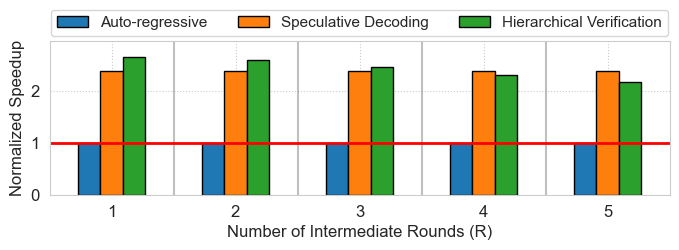

In [306]:
# =========================
# 2. Sweep R with fixed L_SD
# =========================
rows = []
for R in R_values:
    rows.append({
        "R": R,
        "Method": "Auto-regressive",
        "Speedup": 1.0,
    })
    rows.append({
        "R": R,
        "Method": "Speculative Decoding",
        "Speedup": sd_speedup_vs_ar(fixed_L_SD, alpha_SD, T_D, T_T),
    })
    rows.append({
        "R": R,
        "Method": "Hierarchical Verification",
        "Speedup": hv_speedup_vs_ar(fixed_L_SD, R, alpha_HV, T_D, T_I, T_T),
        "Speedup over Vanilla": hv_speedup_vs_ar(fixed_L_SD, R, alpha_HV, T_D, T_I, T_T) / sd_speedup_vs_ar(fixed_L_SD, alpha_SD, T_D, T_T),
    })

df_r = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 2))
methods = df_r["Method"].unique()
colors = {m: palette[i % len(palette)] for i, m in enumerate(methods)}

bar_width = 0.18
x_ticks = np.array(R_values)
x_tick_positions = np.linspace(0, len(x_ticks) - 1, len(x_ticks))
num_bars = len(methods)

for idx, R in enumerate(x_ticks):
    base_x = x_tick_positions[idx]
    positions = [
        base_x - (bar_width * num_bars) / 2 + j * bar_width + bar_width / 2
        for j in range(num_bars)
    ]
    subset = df_r[df_r["R"] == R]
    for i, method in enumerate(methods):
        value = subset[subset["Method"] == method]["Speedup"].values[0]
        ax.bar(
            positions[i],
            value,
            width=bar_width,
            color=colors[method],
            edgecolor="black",
            label=method if idx == 0 else "",
        )

for i in range(len(x_ticks) - 1):
    ax.axvline(x=i + 0.5, color="grey", linestyle="-", alpha=0.5)

ax.set_xticks(x_tick_positions)
ax.set_xticklabels([str(int(x)) for x in x_ticks])
ax.set_xlabel("Number of Intermediate Rounds (R)", fontsize=12)
ax.set_ylabel("Normalized Speedup", fontsize=12)
ax.tick_params(axis="both", which="major", labelsize=12)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(
    by_label.values(),
    by_label.keys(),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.25),
    ncol=3,
    fancybox=True,
    shadow=False,
    fontsize=11,
)

ax.axhline(y=1.0, color="r", linestyle="-", linewidth=2)

ymax = max(1.05, df_r["Speedup"].max() * 1.12)
ax.set_ylim(0.0, ymax)
ax.set_xlim(-0.5, len(x_ticks) - 0.5)

plt.grid(True, linestyle=":")
fig.savefig(os.path.join(plots_dir, "speedup_round_sweep.pdf"), dpi=600, bbox_inches="tight")
plt.show()




In [296]:
# Display Raw Data
display(df_r)

,R,Method,Speedup,Speedup over Vanilla
0,1,Auto-regressive,1.000000,NaN
1,1,Speculative Decoding,2.382678,NaN
2,1,Hierarchical Verification,2.425627,1.018025
3,2,Auto-regressive,1.000000,NaN
4,2,Speculative Decoding,2.382678,NaN
5,2,Hierarchical Verification,2.280026,0.956917
6,3,Auto-regressive,1.000000,NaN
7,3,Speculative Decoding,2.382678,NaN
8,3,Hierarchical Verification,2.053450,0.861825
9,4,Auto-regressive,1.000000,NaN


In [307]:
# Estimate Accetpance Rate Increase

from scipy.optimize import brentq
import numpy as np

def required_alpha_for_acceptance_increase(
    alpha_current: float,
    acceptance_length: float,
    target_increase_pct: float,
    eps: float = 1e-9,
):
    """
    Find alpha_new that increases average acceptance length by target_increase_pct.

    acceptance_length means current average commit length:
        A = (1 - alpha^(L + 1)) / (1 - alpha)

    Since L is not directly given, this function first infers continuous L
    from alpha_current and acceptance_length, then solves alpha_new.
    """

    A_target = acceptance_length * (1.0 + target_increase_pct / 100.0)

    def avg_commit_len(alpha, L):
        if np.isclose(alpha, 1.0):
            return L + 1.0
        return (1.0 - alpha ** (L + 1.0)) / (1.0 - alpha)

    def infer_L(alpha, A):
        def f(L):
            return avg_commit_len(alpha, L) - A
        return brentq(f, eps, 1000.0)

    L = infer_L(alpha_current, acceptance_length)

    max_possible = L + 1.0
    if A_target >= max_possible:
        return {
            "alpha_current": alpha_current,
            "alpha_required": None,
            "L_inferred": L,
            "acceptance_length_current": acceptance_length,
            "acceptance_length_target": A_target,
            "max_possible_acceptance_length": max_possible,
            "feasible": False,
        }

    def g(alpha_new):
        return avg_commit_len(alpha_new, L) - A_target

    alpha_required = brentq(g, eps, 1.0 - eps)

    return {
        "alpha_current": alpha_current,
        "alpha_required": alpha_required,
        "L_inferred": L,
        "acceptance_length_current": acceptance_length,
        "acceptance_length_target": A_target,
        "max_possible_acceptance_length": max_possible,
        "feasible": True,
    }

In [308]:
result = required_alpha_for_acceptance_increase(
    alpha_current=0.80,
    acceptance_length=3.04,
    target_increase_pct=15,
)

result

{'alpha_current': 0.8,
 'alpha_required': 0.886397865362892,
 'L_inferred': 3.196820538510622,
 'acceptance_length_current': 3.04,
 'acceptance_length_target': 3.4959999999999996,
 'max_possible_acceptance_length': 4.196820538510622,
 'feasible': True}

In [309]:
def pivot_acceptance_target(
    base_acceptance_length: float,
    misspeculation_probability: float,
    pivot_reduce_misspec: float,
    speculation_length: int,
):
    """
    Pivot increases acceptance length proportionally to the base acceptance length.

    A_pivot = A_base * (1 + P_misspec * pivot_reduce_misspec)
    """
    target_increase_ratio = 1.0 + (misspeculation_probability + 0.04 * speculation_length) * pivot_reduce_misspec
    target_increase_pct = (target_increase_ratio - 1.0) * 100.0

    delta_A = base_acceptance_length * (target_increase_ratio - 1.0)
    A_target = base_acceptance_length + delta_A

    return {
        "delta_A": delta_A,
        "A_target": A_target,
        "target_increase_ratio": target_increase_ratio,
        "target_increase_pct": target_increase_pct,
    }


def pivot_speedup_vs_ar(
    L_SD,
    alpha_SD,
    T_D,
    T_T,
    misspeculation_probability,
    pivot_top_k,
    pivot_pct,
    pivot_reduce_misspec,
):
    T_D = T_D * L_SD
    A_SD = avg_commit_len(alpha_SD, L_SD)

    pivot_target = pivot_acceptance_target(
        base_acceptance_length=A_SD,
        misspeculation_probability=misspeculation_probability,
        pivot_reduce_misspec=pivot_reduce_misspec,
        speculation_length=L_SD,
    )

    alpha_result = required_alpha_for_acceptance_increase(
        alpha_current=alpha_SD,
        acceptance_length=A_SD,
        target_increase_pct=pivot_target["target_increase_pct"],
    )

    A_pivot = alpha_result["acceptance_length_target"]
    alpha_pivot = alpha_result["alpha_required"]

    # expansion_factor = 1.0 + pivot_pct * (pivot_top_k - 1)
    # expansion_factor = 1.0 # Oracle
    expansion_factor = 1.3 # Experimental (increasing batch size by two increases 10% execution time overhead)

    T_AR_total = S_AR * T_T
    T_pivot_total = (S_AR / A_pivot) * expansion_factor * (T_D + T_T)

    speedup = T_AR_total / T_pivot_total

    return {
        "speedup": speedup,
        "alpha_pivot": alpha_pivot,
        "A_pivot": A_pivot,
        "A_SD": A_SD,
        "delta_A": pivot_target["delta_A"],
        "A_target": pivot_target["A_target"],
        "target_increase_ratio": pivot_target["target_increase_ratio"],
        "target_increase_pct": pivot_target["target_increase_pct"],
        "expansion_factor": expansion_factor,
        "feasible": alpha_result["feasible"],
    }


def pivot_hv_speedup_vs_ar(
    L_SD,
    R,
    alpha_HV,
    T_D,
    T_I,
    T_T,
    misspeculation_probability,
    pivot_top_k,
    pivot_pct,
    pivot_reduce_misspec,
):
    T_D = T_D * L_SD
    L_HV = (L_SD + 1) * R + L_SD
    A_HV = avg_commit_len(alpha_HV, L_HV)

    pivot_target = pivot_acceptance_target(
        base_acceptance_length=A_HV,
        misspeculation_probability=misspeculation_probability,
        pivot_reduce_misspec=pivot_reduce_misspec,
        speculation_length=L_HV,
    )

    alpha_result = required_alpha_for_acceptance_increase(
        alpha_current=alpha_HV,
        acceptance_length=A_HV,
        target_increase_pct=pivot_target["target_increase_pct"],
    )

    A_pivot_hv = alpha_result["acceptance_length_target"]
    alpha_pivot_hv = alpha_result["alpha_required"]
    
    # expansion_factor = 1.0 + pivot_pct * (pivot_top_k - 1)
    # expansion_factor = 1 # Oracle
    expansion_factor = 1.3 # Experimental (increasing batch size by two increases 10% execution time overhead)
    hv_cost_per_step = (R + 1) * T_D + R * T_I + (T_T * 1.2)

    T_AR_total = S_AR * T_T
    T_pivot_hv_total = (S_AR / A_pivot_hv) * expansion_factor * hv_cost_per_step

    speedup = T_AR_total / T_pivot_hv_total

    return {
        "speedup": speedup,
        "alpha_pivot_hv": alpha_pivot_hv,
        "A_pivot_hv": A_pivot_hv,
        "A_HV": A_HV,
        "L_HV": L_HV,
        "delta_A": pivot_target["delta_A"],
        "A_target": pivot_target["A_target"],
        "target_increase_ratio": pivot_target["target_increase_ratio"],
        "target_increase_pct": pivot_target["target_increase_pct"],
        "expansion_factor": expansion_factor,
        "feasible": alpha_result["feasible"],
    }


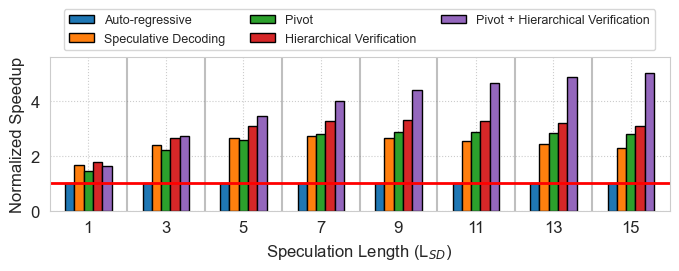

In [310]:
# =========================
# 1. Sweep L_SD
# =========================
rows = []

for L_SD in L_SD_values:
    sd_result = sd_speedup_vs_ar(L_SD, alpha_SD, T_D, T_T)
    hv_result = hv_speedup_vs_ar(L_SD, fixed_R, alpha_HV, T_D, T_I, T_T)

    pivot_result = pivot_speedup_vs_ar(
        L_SD=L_SD,
        alpha_SD=alpha_SD,
        T_D=T_D,
        T_T=T_T,
        misspeculation_probability=misspeculation_probability,
        pivot_top_k=pivot_top_k,
        pivot_pct=pivot_pct,
        pivot_reduce_misspec=pivot_reduce_misspec,
    )

    pivot_hv_result = pivot_hv_speedup_vs_ar(
        L_SD=L_SD,
        R=fixed_R,
        alpha_HV=alpha_HV,
        T_D=T_D,
        T_I=T_I,
        T_T=T_T,
        misspeculation_probability=misspeculation_probability,
        pivot_top_k=pivot_top_k,
        pivot_pct=pivot_pct,
        pivot_reduce_misspec=pivot_reduce_misspec,
    )

    rows.append({
        "L_SD": L_SD,
        "Method": "Auto-regressive",
        "Speedup": 1.0,
        "Speedup over Vanilla": np.nan,
        "Speedup over HV": np.nan,
        "Alpha": np.nan,
        "Avg Commit Length": 1.0,
        "Expansion Factor": 1.0,
    })

    rows.append({
        "L_SD": L_SD,
        "Method": "Speculative Decoding",
        "Speedup": sd_result,
        "Speedup over Vanilla": 1.0,
        "Speedup over HV": np.nan,
        "Alpha": alpha_SD,
        "Avg Commit Length": avg_commit_len(alpha_SD, L_SD),
        "Expansion Factor": 1.0,
    })

    rows.append({
        "L_SD": L_SD,
        "Method": "Pivot",
        "Speedup": pivot_result["speedup"],
        "Speedup over Vanilla": pivot_result["speedup"] / sd_result,
        "Speedup over HV": np.nan,
        "Alpha": pivot_result["alpha_pivot"],
        "Avg Commit Length": pivot_result["A_SD"],
        "Expansion Factor": pivot_result["expansion_factor"],
        "Pivot Avg Commit Length": pivot_result["A_pivot"],
    })

    rows.append({
        "L_SD": L_SD,
        "Method": "Hierarchical Verification",
        "Speedup": hv_result,
        "Speedup over Vanilla": hv_result / sd_result,
        "Speedup over HV": 1.0,
        "Alpha": alpha_HV,
        "Avg Commit Length": avg_commit_len(alpha_HV, (L_SD + 1) * fixed_R + L_SD),
        "Expansion Factor": np.nan,
    })

    rows.append({
        "L_SD": L_SD,
        "Method": "Pivot + Hierarchical Verification",
        "Speedup": pivot_hv_result["speedup"],
        "Speedup over Vanilla": pivot_hv_result["speedup"] / sd_result,
        "Speedup over HV": pivot_hv_result["speedup"] / hv_result,
        "Alpha": pivot_hv_result["alpha_pivot_hv"],
        "Avg Commit Length": pivot_hv_result["A_HV"],
        "Effective L": pivot_hv_result["L_HV"],
        "Expansion Factor": pivot_hv_result["expansion_factor"],
        "Pivot Avg Commit Length": pivot_hv_result["A_pivot_hv"],
    })

df_lsd = pd.DataFrame(rows)

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(8, 2))

palette = sns.color_palette("tab10")
methods = df_lsd["Method"].unique()
colors = {m: palette[i % len(palette)] for i, m in enumerate(methods)}

bar_width = 0.12
x_ticks = np.array(L_SD_values)
x_tick_positions = np.linspace(0, len(x_ticks) - 1, len(x_ticks))
num_bars = len(methods)

for idx, L_SD in enumerate(x_ticks):
    base_x = x_tick_positions[idx]
    positions = [
        base_x - (bar_width * num_bars) / 2 + j * bar_width + bar_width / 2
        for j in range(num_bars)
    ]

    subset = df_lsd[df_lsd["L_SD"] == L_SD]

    for i, method in enumerate(methods):
        value = subset[subset["Method"] == method]["Speedup"].values[0]
        ax.bar(
            positions[i],
            value,
            width=bar_width,
            color=colors[method],
            edgecolor="black",
            label=method if idx == 0 else "",
        )

for i in range(len(x_ticks) - 1):
    ax.axvline(x=i + 0.5, color="grey", linestyle="-", alpha=0.5)

ax.set_xticks(x_tick_positions)
ax.set_xticklabels([str(int(x)) for x in x_ticks])

ax.set_xlabel("Speculation Length (L$_{SD}$)", fontsize=12)
ax.set_ylabel("Normalized Speedup", fontsize=12)
ax.tick_params(axis="both", which="major", labelsize=12)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

ax.legend(
    by_label.values(),
    by_label.keys(),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.35),
    ncol=3,
    fancybox=True,
    shadow=False,
    fontsize=9,
)

ax.axhline(y=1.0, color="r", linestyle="-", linewidth=2)

ymax = max(1.05, df_lsd["Speedup"].max() * 1.12)
ax.set_ylim(0.0, ymax)
ax.set_xlim(-0.5, len(x_ticks) - 0.5)

plt.grid(True, linestyle=":")

fig.savefig(
    os.path.join(plots_dir, "speedup_lsd_sweep_with_pivot.pdf"),
    dpi=600,
    bbox_inches="tight",
)

plt.show()



In [311]:
display(df_lsd[df_lsd["Method"] == "Pivot"].round(2))

,L_SD,Method,Speedup,Speedup over Vanilla,Speedup over HV,Alpha,Avg Commit Length,Expansion Factor,Pivot Avg Commit Length,Effective L
2,1,Pivot,1.46,0.88,NaN,NaN,1.85,1.3,2.11,NaN
7,3,Pivot,2.21,0.93,NaN,0.97,3.18,1.3,3.83,NaN
12,5,Pivot,2.60,0.98,NaN,0.95,4.13,1.3,5.25,NaN
17,7,Pivot,2.78,1.03,NaN,0.94,4.82,1.3,6.43,NaN
22,9,Pivot,2.86,1.08,NaN,0.93,5.31,1.3,7.43,NaN
27,11,Pivot,2.87,1.12,NaN,0.93,5.67,1.3,8.29,NaN
32,13,Pivot,2.85,1.17,NaN,0.93,5.92,1.3,9.04,NaN
37,15,Pivot,2.80,1.22,NaN,0.93,6.11,1.3,9.71,NaN


In [312]:
display(df_lsd[df_lsd["Method"] == "Pivot + Hierarchical Verification"].round(2))

,L_SD,Method,Speedup,Speedup over Vanilla,Speedup over HV,Alpha,Avg Commit Length,Expansion Factor,Pivot Avg Commit Length,Effective L
4,1,Pivot + Hierarchical Verification,1.65,0.99,0.93,NaN,3.71,1.3,4.48,3.0
9,3,Pivot + Hierarchical Verification,2.73,1.14,1.03,NaN,6.73,1.3,8.98,7.0
14,5,Pivot + Hierarchical Verification,3.47,1.31,1.12,NaN,9.19,1.3,13.44,11.0
19,7,Pivot + Hierarchical Verification,4.00,1.48,1.22,NaN,11.20,1.3,17.81,15.0
24,9,Pivot + Hierarchical Verification,4.39,1.65,1.32,NaN,12.83,1.3,22.05,19.0
29,11,Pivot + Hierarchical Verification,4.67,1.83,1.42,NaN,14.16,1.3,26.15,23.0
34,13,Pivot + Hierarchical Verification,4.87,2.01,1.52,NaN,15.24,1.3,30.10,27.0
39,15,Pivot + Hierarchical Verification,5.02,2.19,1.62,NaN,16.13,1.3,33.90,31.0
